# Innovation Diffusion Analysis

#### - Innovation: **Philips Norelco i9000 Prestige Ultra**
#### - Source: **TIME Best Inventions 2025**
#### - Analog innovation: **Electric shavers**

### **Data Source**


Market data was derived from the global electric shaver market report by Data Bridge Market Research.

Historical market values were reconstructed using the CAGR provided in the Data Bridge Market Research report. This estimation approach follows Fermi-style reasoning when full time-series datasets are unavailable.

Because the report provides the most recent market size and growth rate but not a complete historical dataset, earlier values were estimated using the compound annual growth rate(CAGR) formula.

### **Why CAGR Reconstruction Was Used**



Many market research reports provide summary statistics such as market size and compound annual growth rate (CAGR) but do not provide raw historical time series.

To reconstruct the dataset, we used the CAGR formula:

`Value_t = Value_(t-1) * (1 + CAGR)`

Rearranging allows us to estimate earlier values:

`Value_(t-1) = Value_t / (1 + CAGR)`

This approach is commonly used in marketing analytics when only partial market data is available.

### Load Data

In [39]:
import sys
import os

sys.path.append(os.path.abspath(".."))
import pandas as pd
from dataset_with_cagr import GenerateData

data = GenerateData()

    Year  Market_Billion_USD
0   2010                6.52
1   2011                6.83
2   2012                7.15
3   2013                7.48
4   2014                7.83
5   2015                8.20
6   2016                8.59
7   2017                8.99
8   2018                9.41
9   2019                9.86
10  2020               10.32
11  2021               10.80
12  2022               11.31
13  2023               11.84
14  2024               12.40


### Visualize Market Growth

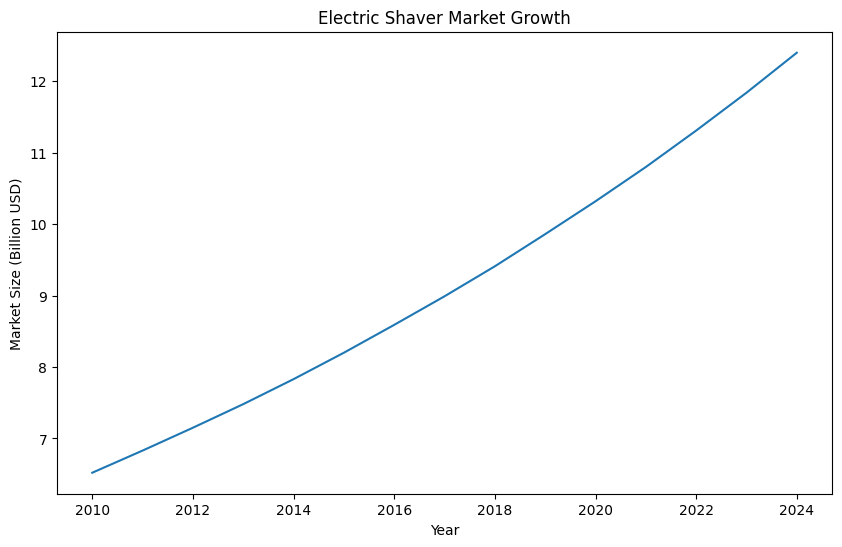

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(data["Year"],data["Market_Billion_USD"])
plt.title("Electric Shaver Market Growth")
plt.xlabel("Year")
plt.ylabel("Market Size (Billion USD)")
plt.savefig("img/market_growth.png")
plt.show()

#### Bass Model

In [41]:
import numpy as np
from scipy.optimize import curve_fit
from utils import bass_model
from loguru import logger

**Bass Model Equation**

`f(t) = (p + qF(t))(1 − F(t))`

`p` = coefficient of innovation  
`q` = coefficient of imitation  
`M` = market potential

#### Parameter Estimation

In [42]:
sales = data["Market_Billion_USD"].values * 10

t = np.arange(len(sales))

params,_ = curve_fit(bass_model,t,sales,bounds=(0,[1,1,1000]))

p,q,M = params

logger.info("p = {}", p)
logger.info("q = {}", q)
logger.info("M = {}", M)

2026-03-07 20:36:42.865 | INFO     | __main__:<module>:9 - p = 0.016992522532910906
2026-03-07 20:36:42.866 | INFO     | __main__:<module>:10 - q = 0.328833687649555
2026-03-07 20:36:42.867 | INFO     | __main__:<module>:11 - M = 999.9999192846085


#### Diffusion Prediction

In [43]:
future_t = np.arange(30)
predicted = bass_model(future_t,p,q,M)

### Diffusion Curve

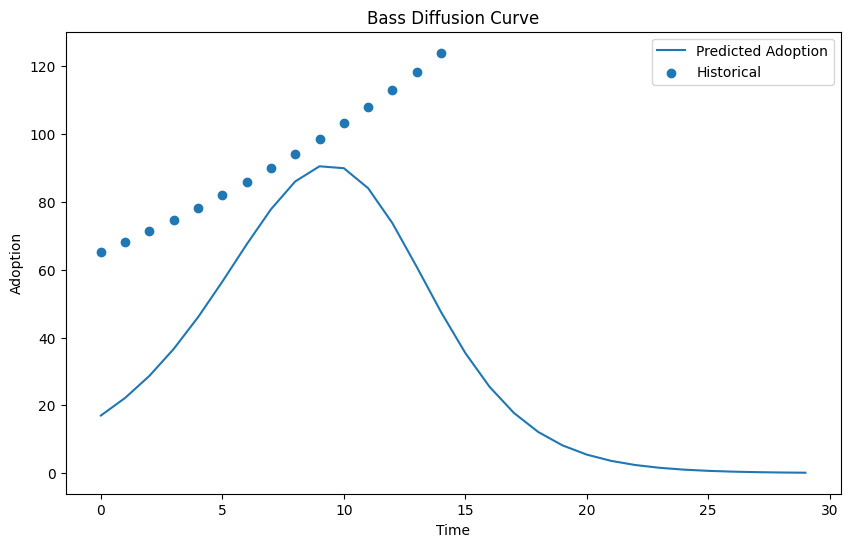

In [44]:
plt.figure(figsize=(10,6))
plt.plot(predicted,label="Predicted Adoption")
plt.scatter(t,sales,label="Historical")
plt.legend()
plt.title("Bass Diffusion Curve")
plt.xlabel("Time")
plt.ylabel("Adoption")
plt.savefig("img/diffusion_curve.png")
plt.show()

### Cumulative Adoption

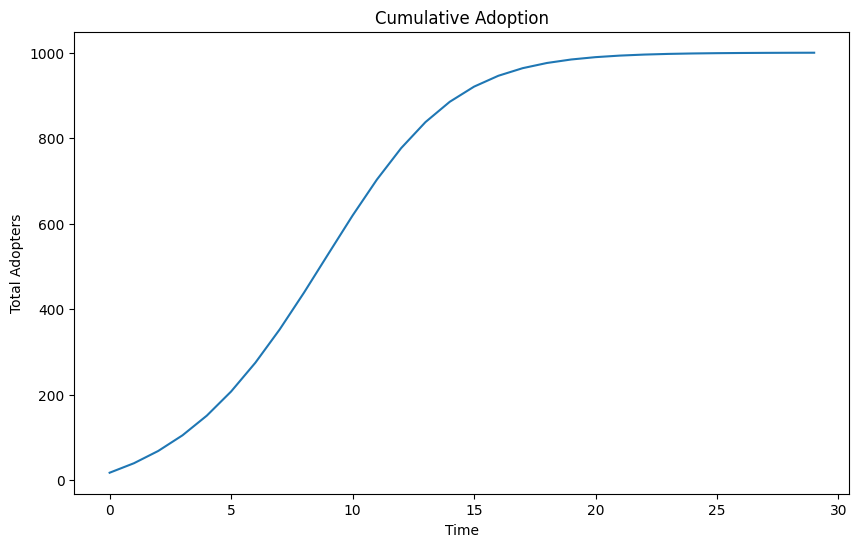

In [45]:
cumulative = np.cumsum(predicted)
plt.figure(figsize=(10,6))
plt.plot(cumulative)
plt.title("Cumulative Adoption")
plt.xlabel("Time")
plt.ylabel("Total Adopters")
plt.savefig("img/cumulative_adoption_curve.png")
plt.show()